In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# download historical data
ticker = "AAPL"
apple_df = yf.download(ticker, start="2020-01-01", end="2025-07-01")

# if index is not the date column:
#   df.set_index("Date", inplace=True)

# if index is not a datetime, convert it:
#   df.index = pd.to_datetime(df.index)



# 2. preview data
print(apple_df.head())



/var/folders/wc/8wws1lfd3kv91ykflkc2lzxc0000gn/T/ipykernel_98828/2747595104.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple_df = yf.download(ticker, start="2020-01-01", end="2025-07-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.620827  72.681274  71.373203  71.627077  135480400
2020-01-03  71.914810  72.676439  71.689950  71.847110  146322800
2020-01-06  72.487854  72.526541  70.783256  71.034717  118387200
2020-01-07  72.146942  72.753823  71.926915  72.497529  108872000
2020-01-08  73.307518  73.609752  71.849540  71.849540  132079200


In [ ]:
# flatten multi-index column
apple_df.columns = apple_df.columns.get_level_values(0)

# confirm Date is datetime index
apple_df.index = pd.to_datetime(apple_df.index)

# df with just closing price
apple_ts = apple_df['Close']

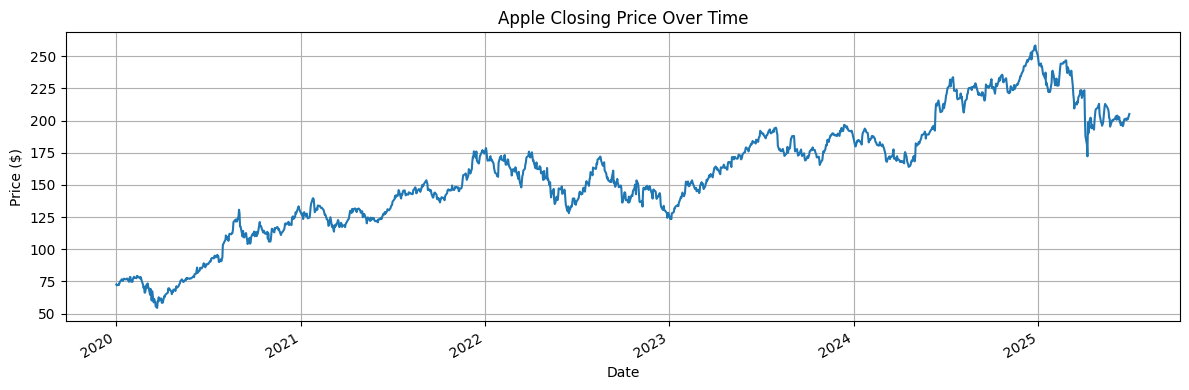

In [7]:

plt.figure(figsize=(12, 4))
apple_ts.plot()
plt.title("Apple Closing Price Over Time")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
# apple_df.dtypes 
apple_df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.620827,72.681274,71.373203,71.627077,135480400
2020-01-03,71.914810,72.676439,71.689950,71.847110,146322800
2020-01-06,72.487854,72.526541,70.783256,71.034717,118387200
2020-01-07,72.146942,72.753823,71.926915,72.497529,108872000
2020-01-08,73.307518,73.609752,71.849540,71.849540,132079200


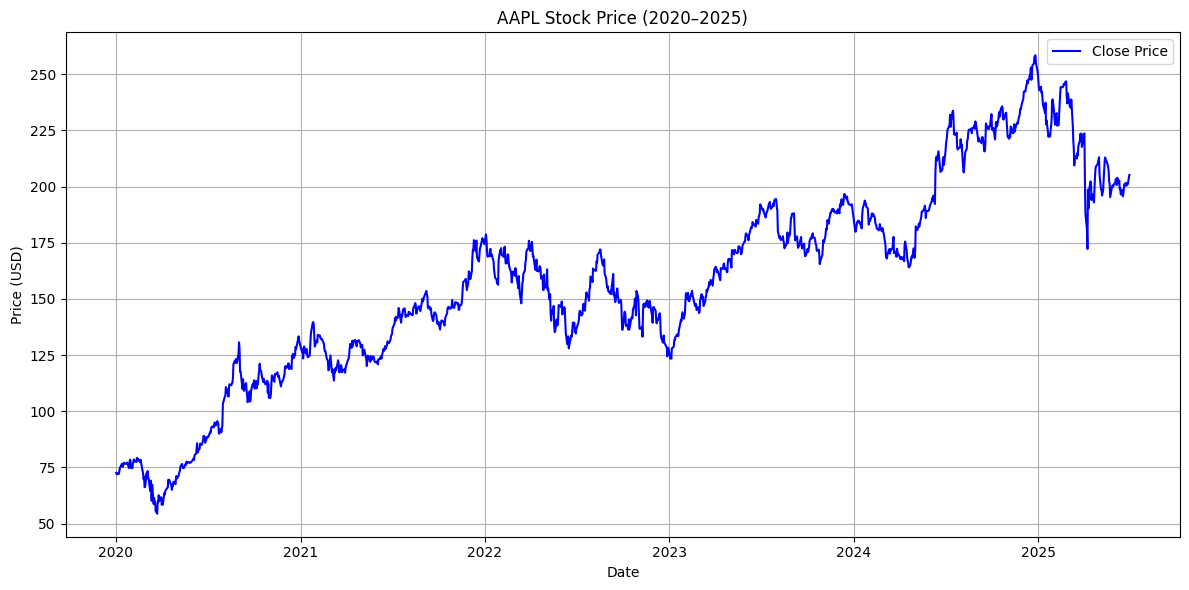

In [ ]:
# plot closing price over time
plt.figure(figsize=(12, 6))
plt.plot(apple_df.index, apple_df["Close"], label="Close Price", color="blue")
plt.title(f"{ticker} Stock Price (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Naive Forecast RMSE: 10.68


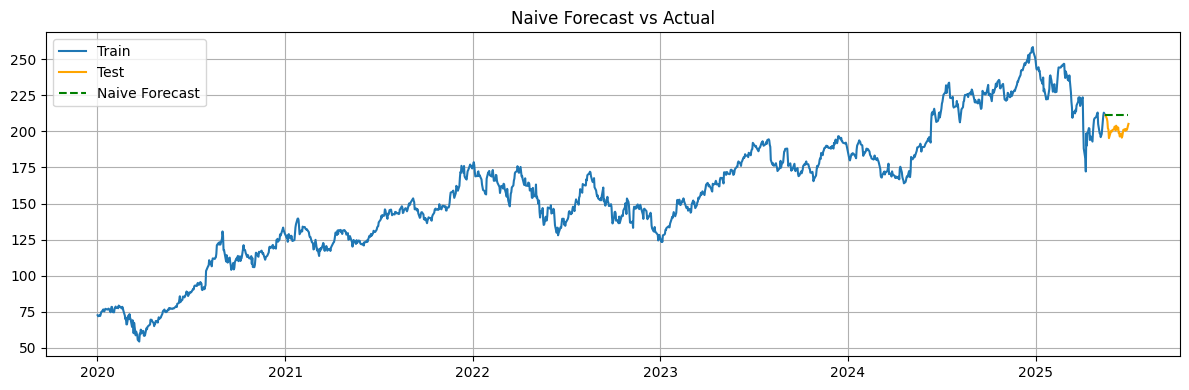

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# train/test split (last 30 days for testing)
train = apple_ts[:-30]
test = apple_ts[-30:]

# naive forecast: predict each test point as the last train value
naive_forecast = np.repeat(train.iloc[-1], len(test))

# calculate RMSE
rmse = np.sqrt(mean_squared_error(test, naive_forecast))
print(f"Naive Forecast RMSE: {rmse:.2f}")

# plot
plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, naive_forecast, label='Naive Forecast', color='green', linestyle='--')
plt.title("Naive Forecast vs Actual")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
"""
Naive Model for Apple Stock
Fit the ARIMA model (1 AR term, 1 difference, 1 MA term)
	•	1st order differencing (d=1) to remove trend
	•	One lag term (p=1) and one error term (q=1)
"""

model = ARIMA(apple_ts, order=(1, 1, 1))
model_fit = model.fit()

# View model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1380
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3461.245
Date:                Tue, 05 Aug 2025   AIC                           6928.489
Time:                        14:34:31   BIC                           6944.177
Sample:                             0   HQIC                          6934.358
                               - 1380                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6096      0.470     -1.298      0.194      -1.530       0.311
ma.L1          0.5902      0.475      1.241      0.215      -0.342       1.522
sigma2         8.8647      0.160     55.249      0.0

/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive par

In [19]:
# Set frequency to business days
apple_ts = apple_ts.asfreq('B')

In [ ]:
# check to determine if there are nulls after index frequency is set
apple_ts.isna().sum()

np.int64(0)

In [ ]:
# forward fill for missing days
apple_ts = apple_ts.ffill()

ARIMA(1,1,1) Forecast RMSE: 8.86


/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


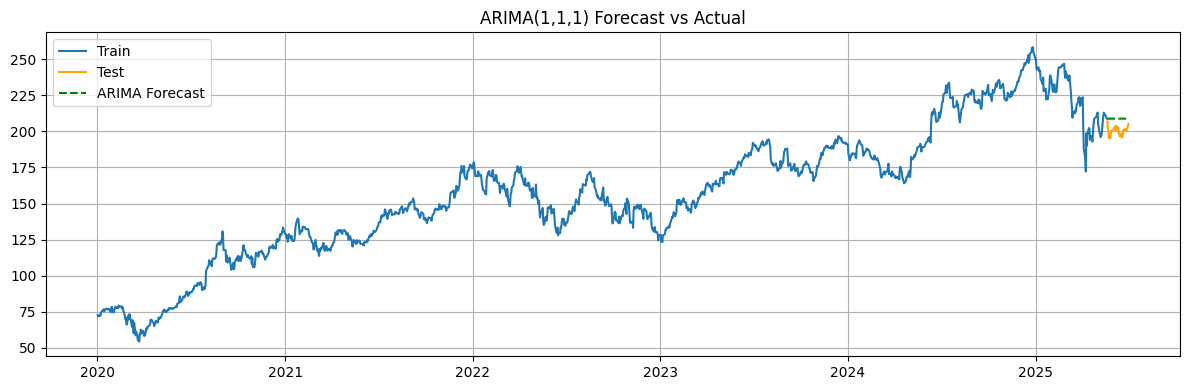

In [23]:
# Use same train/test split
train = apple_ts[:-30]
test = apple_ts[-30:]

# Refit ARIMA on the training data
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# Forecast next 30 business days
forecast = model_fit.forecast(steps=30)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"ARIMA(1,1,1) Forecast RMSE: {rmse:.2f}")

# Plot results
plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(forecast.index, forecast, label='ARIMA Forecast', color='green', linestyle='--')
plt.title("ARIMA(1,1,1) Forecast vs Actual")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Tuning ARIMA model

In [ ]:
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# suppress warnings
warnings.filterwarnings("ignore")

# split data
train = apple_ts[:-30]
test = apple_ts[-30:]

# define grid
p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)

best_rmse = float('inf')
best_order = None
results = []

# Grid search
for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train, order=(p, d, q))
                model_fit = model.fit()
                forecast = model_fit.forecast(steps=30)
                rmse = mean_squared_error(test, forecast) ** 0.5
                aic = model_fit.aic
                results.append(((p, d, q), rmse, aic))
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_order = (p, d, q)
            except:
                continue

print(f"Best ARIMA Order: {best_order} with RMSE: {best_rmse:.2f}")

Best ARIMA Order: (2, 0, 2) with RMSE: 7.69


In [27]:
# # debug output from parameter grid above: print failures
# for p in p_values:
#     for d in d_values:
#         for q in q_values:
#             try:
#                 model = ARIMA(train, order=(p, d, q))
#                 model_fit = model.fit()
#                 forecast = model_fit.forecast(steps=30)
#                 rmse = mean_squared_error(test, forecast, squared=False)
#                 aic = model_fit.aic
#                 results.append(((p, d, q), rmse, aic))
#                 if rmse < best_rmse:
#                     best_rmse = rmse
#                     best_order = (p, d, q)
#             except Exception as e:
#                 print(f"Failed for order=({p},{d},{q}) — {e}")

# # issue with syntax due to python version

In [ ]:

📦 What Next?

Here are your options:
	1.	Fit ARIMA(2,0,2) for real and visualize the forecast
	2.	Try SARIMA if you suspect seasonality
	3.	Run ADF test to check if differencing (d=1) is needed at all
	4.	Look at residuals to see if any structure remains

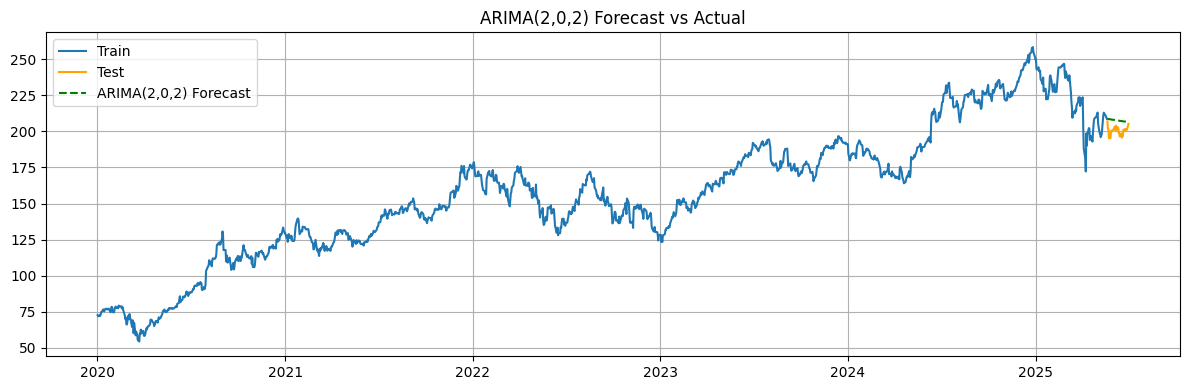

In [28]:
# model fit an forecasting with best_model from tuning

# refit best ARIMA model on training data
best_model = ARIMA(train, order=(2, 0, 2))
best_model_fit = best_model.fit()

# Forecast next 30 business days
forecast = best_model_fit.forecast(steps=30)

# Plot forecast vs actual
plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(forecast.index, forecast, label='ARIMA(2,0,2) Forecast', color='green', linestyle='--')
plt.title("ARIMA(2,0,2) Forecast vs Actual")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()